In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [ ]:
BASE_DIR = Path(".")
PROCESSED_DIR = BASE_DIR / "data" / "processed"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
estate = pd.read_csv(PROCESSED_DIR / "estate_master_cleaned.csv")
weather = pd.read_csv(PROCESSED_DIR / "weather_data_cleaned.csv")
operation = pd.read_csv(PROCESSED_DIR / "operation_data_cleaned.csv")
production = pd.read_csv(PROCESSED_DIR / "production_data_cleaned.csv")

In [ ]:
print("Estate:", estate.shape)
print("Weather:", weather.shape)
print("Operation:", operation.shape)
print("Production:", production.shape)

Estate: (10, 5)
Weather: (840, 4)
Operation: (840, 5)
Production: (840, 8)


In [ ]:
# Convert Date
weather["date"] = pd.to_datetime(weather["date"])
operation["date"] = pd.to_datetime(operation["date"])
production["date"] = pd.to_datetime(production["date"])

## Gabungkan Dataset

In [ ]:
df = production.merge(
    weather,
    on=["date", "estate_id"],
    how="left"
)

df = df.merge(
    operation,
    on=["date", "estate_id"],
    how="left"
)

df = df.merge(
    estate,
    on="estate_id",
    how="left"
)

In [ ]:
df.shape
df

,date,estate_id,tbs_production_ton,cpo_production_ton,kernel_production_ton,tbs_outlier_flag,cpo_extraction_rate,kernel_extraction_rate,rainfall_mm,rainy_days,fertilizer_kg,working_days,disruption_days,estate_name,region,area_ha,planting_year
0,2019-01-01,EST001,8132.4,1600.4,487.9,False,0.196793,0.059995,265.40,18.0,44558.0,25.0,0.0,Estate Lampung 01,Sumatra,4250,2010
1,2019-02-01,EST001,8492.3,1805.1,443.2,False,0.212557,0.052188,238.50,17.0,51306.0,23.0,1.0,Estate Lampung 01,Sumatra,4250,2010
2,2019-03-01,EST001,8186.5,1597.9,413.1,False,0.195187,0.050461,247.20,15.0,43954.0,23.0,0.0,Estate Lampung 01,Sumatra,4250,2010
3,2019-04-01,EST001,7936.4,1398.5,415.7,False,0.176213,0.052379,247.10,17.0,36406.0,23.0,3.0,Estate Lampung 01,Sumatra,4250,2010
4,2019-05-01,EST001,8551.4,1856.5,513.1,False,0.217099,0.060002,192.10,13.0,41455.0,25.0,0.0,Estate Lampung 01,Sumatra,4250,2010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,2025-08-01,EST010,9326.8,1829.3,425.5,False,0.196134,0.045621,161.70,10.0,53906.0,26.0,1.0,Estate Sulawesi 02,Sulawesi,4300,2012
836,2025-09-01,EST010,9624.3,1833.0,506.9,False,0.190455,0.052669,209.80,16.0,45029.0,25.0,1.0,Estate Sulawesi 02,Sulawesi,4300,2012
837,2025-10-01,EST010,8785.7,1682.7,403.9,False,0.191527,0.045972,165.00,13.0,49816.0,24.0,0.0,Estate Sulawesi 02,Sulawesi,4300,2012
838,2025-11-01,EST010,8879.5,2025.1,434.4,False,0.228065,0.048922,191.95,17.0,46785.0,22.0,1.0,Estate Sulawesi 02,Sulawesi,4300,2012


## Variable Turunan

In [ ]:
# plant age
df["plant_age_years"] = (
    df["date"].dt.year - df["planting_year"]
)

In [ ]:
# Production yield
df["tbs_yield_ton_per_ha"] = (
    df["tbs_production_ton"] / df["area_ha"]
)

In [ ]:
# extraction rate
df["cpo_extraction_rate"] = (
    df["cpo_production_ton"] /
    df["tbs_production_ton"]
)

df["kernel_extraction_rate"] = (
    df["kernel_production_ton"] /
    df["tbs_production_ton"]
)

In [ ]:
# month
df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.strftime("%b")
df["year"] = df["date"].dt.year

## Dataset Overview

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    840 non-null    datetime64[ns]
 1   estate_id               840 non-null    object        
 2   tbs_production_ton      840 non-null    float64       
 3   cpo_production_ton      840 non-null    float64       
 4   kernel_production_ton   840 non-null    float64       
 5   tbs_outlier_flag        840 non-null    bool          
 6   cpo_extraction_rate     840 non-null    float64       
 7   kernel_extraction_rate  840 non-null    float64       
 8   rainfall_mm             840 non-null    float64       
 9   rainy_days              840 non-null    float64       
 10  fertilizer_kg           840 non-null    float64       
 11  working_days            840 non-null    float64       
 12  disruption_days         840 non-null    float64   

In [ ]:
df.describe()

,date,tbs_production_ton,cpo_production_ton,kernel_production_ton,cpo_extraction_rate,kernel_extraction_rate,rainfall_mm,rainy_days,fertilizer_kg,working_days,disruption_days,area_ha,planting_year,plant_age_years,tbs_yield_ton_per_ha,month,year
count,840,840.000000,840.000000,840.00000,840.000000,840.000000,840.000000,840.000000,840.000000,840.000000,840.000000,840.000000,840.000000,840.000000,840.000000,840.000000,840.000000
mean,2022-06-16 14:17:08.571428608,9460.278690,1887.297500,472.16369,0.199413,0.049878,219.151071,14.747619,43857.622619,24.035714,1.180952,4385.000000,2011.000000,11.000000,2.150980,6.500000,2022.000000
min,2019-01-01 00:00:00,5563.700000,1017.300000,222.60000,0.154350,0.038982,116.500000,5.000000,27048.000000,22.000000,0.000000,3600.000000,2008.000000,5.000000,1.441974,1.000000,2019.000000
25%,2020-09-23 12:00:00,8051.775000,1584.400000,398.57500,0.188569,0.046217,187.900000,13.000000,37646.875000,23.000000,0.000000,3900.000000,2010.000000,9.000000,1.970440,3.750000,2020.000000
50%,2022-06-16 00:00:00,9327.600000,1871.450000,462.05000,0.199095,0.049795,215.950000,15.000000,43484.500000,24.000000,1.000000,4275.000000,2011.000000,11.000000,2.130165,6.500000,2022.000000
75%,2024-03-08 18:00:00,10727.000000,2159.425000,540.02500,0.210496,0.053545,246.950000,17.000000,49057.250000,25.000000,2.000000,4700.000000,2012.000000,13.000000,2.339390,9.250000,2024.000000
max,2025-12-01 00:00:00,14640.500000,3308.400000,878.40000,0.232326,0.060118,352.000000,24.000000,67944.000000,26.000000,5.000000,5500.000000,2014.000000,17.000000,2.933098,12.000000,2025.000000
std,NaN,1807.517968,391.357354,104.28492,0.014990,0.005078,41.604817,3.175535,8129.898153,1.397225,1.059885,566.044553,1.733083,2.647328,0.260045,3.454109,2.001192


In [ ]:
print("Jumlah estate:", df["estate_id"].nunique())
print("Jumlah region:", df["region"].nunique())
print("Periode:", df["date"].min(), "sampai", df["date"].max())

Jumlah estate: 10
Jumlah region: 3
Periode: 2019-01-01 00:00:00 sampai 2025-12-01 00:00:00


## Cek Kembali Missing Values

In [ ]:
missing_summary = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

missing_summary[missing_summary > 0]

,0


## Tren Produksi Bulanan

#### Yang kita cari dari grafik ini:
- overall trend
- seasonal fluctuation
- abnormal spikes
- declining/increasing production
- pola yang berulang setiap tahun

In [ ]:
# Agregasikan seluruh estate:
monthly_production = (
    df.groupby("date")
      [["tbs_production_ton",
        "cpo_production_ton",
        "kernel_production_ton"]]
      .sum()
      .reset_index()
)

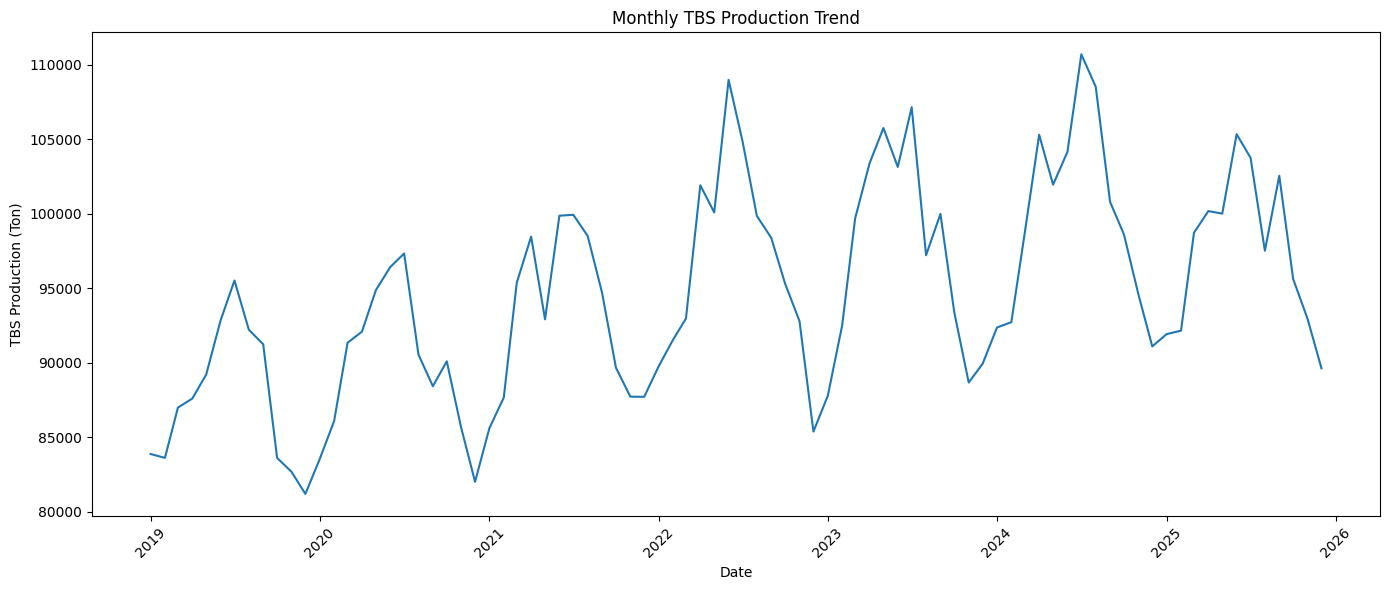

In [ ]:
# Plot TBS
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_production["date"],
    monthly_production["tbs_production_ton"]
)

plt.title("Monthly TBS Production Trend")
plt.xlabel("Date")
plt.ylabel("TBS Production (Ton)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

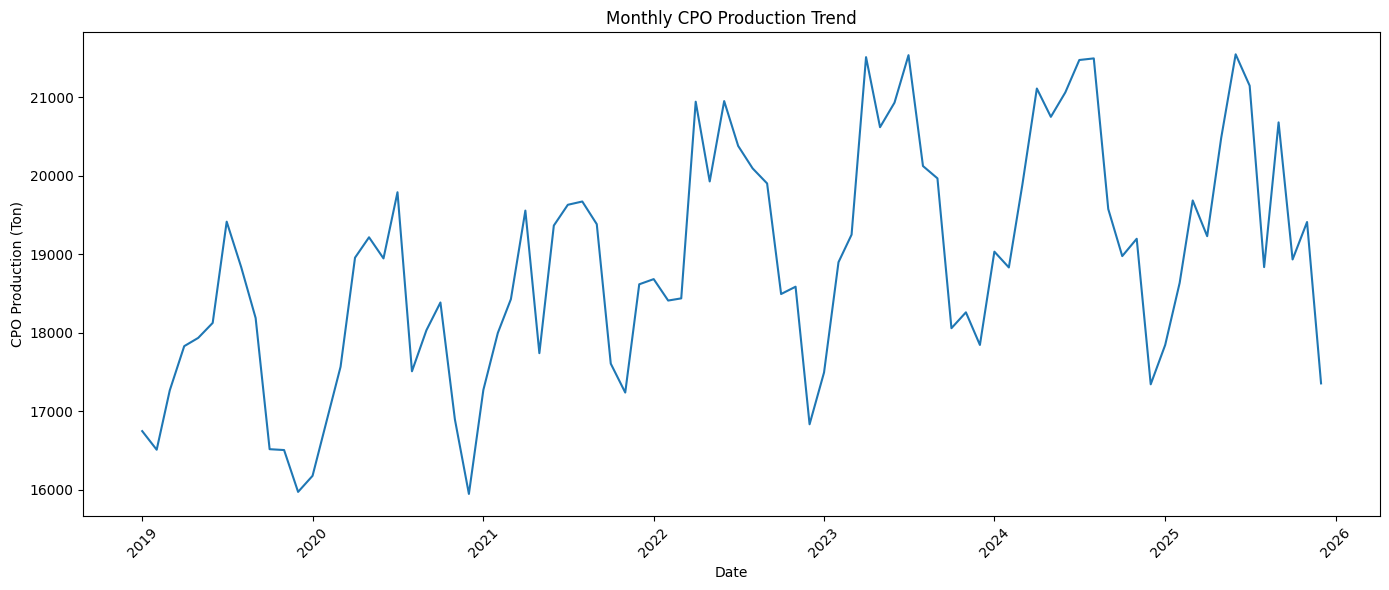

In [ ]:
# CPO
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_production["date"],
    monthly_production["cpo_production_ton"]
)

plt.title("Monthly CPO Production Trend")
plt.xlabel("Date")
plt.ylabel("CPO Production (Ton)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

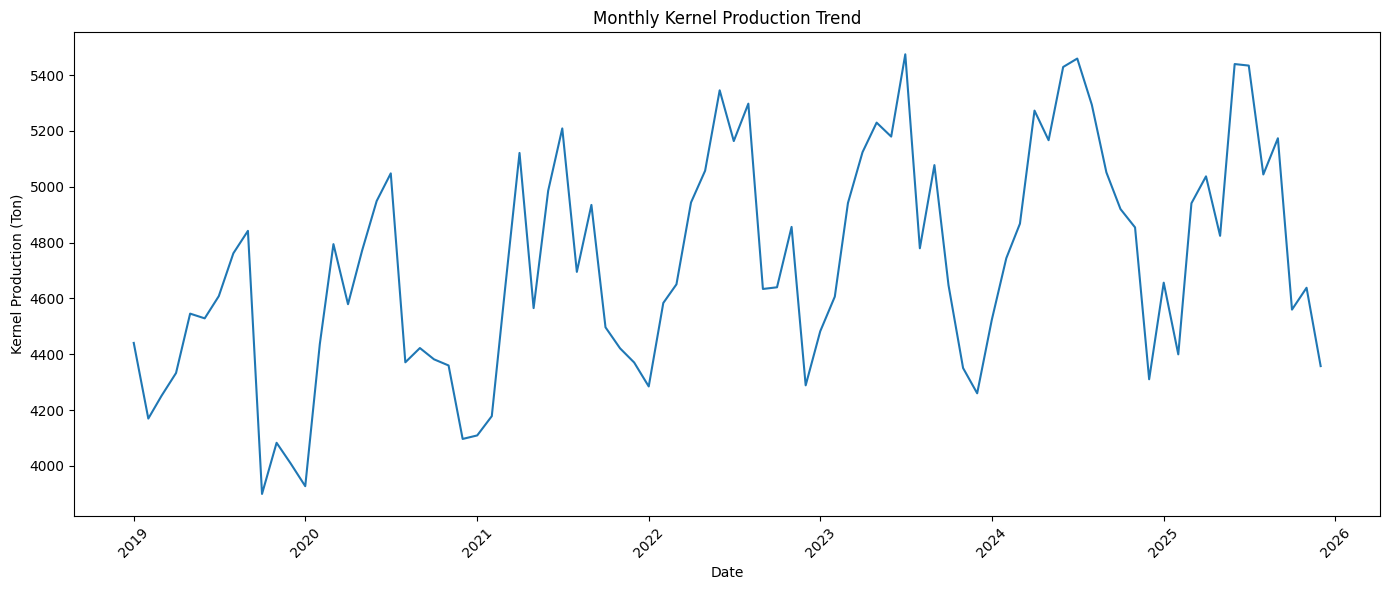

In [ ]:
# Kernel
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_production["date"],
    monthly_production["kernel_production_ton"]
)

plt.title("Monthly Kernel Production Trend")
plt.xlabel("Date")
plt.ylabel("Kernel Production (Ton)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Annual Production

In [ ]:
annual_production = (
    df.groupby("year")
      [["tbs_production_ton",
        "cpo_production_ton",
        "kernel_production_ton"]]
      .sum()
      .reset_index()
)

annual_production

,year,tbs_production_ton,cpo_production_ton,kernel_production_ton
0,2019,1050490.25,209847.7,52469.1
1,2020,1078303.90,214319.1,54136.3
2,2021,1118027.40,222506.5,55716.2
3,2022,1161703.90,231642.1,57745.0
4,2023,1168450.30,234492.4,58153.2
5,2024,1199433.15,238737.1,59892.2
6,2025,1170225.20,233785.0,58505.5


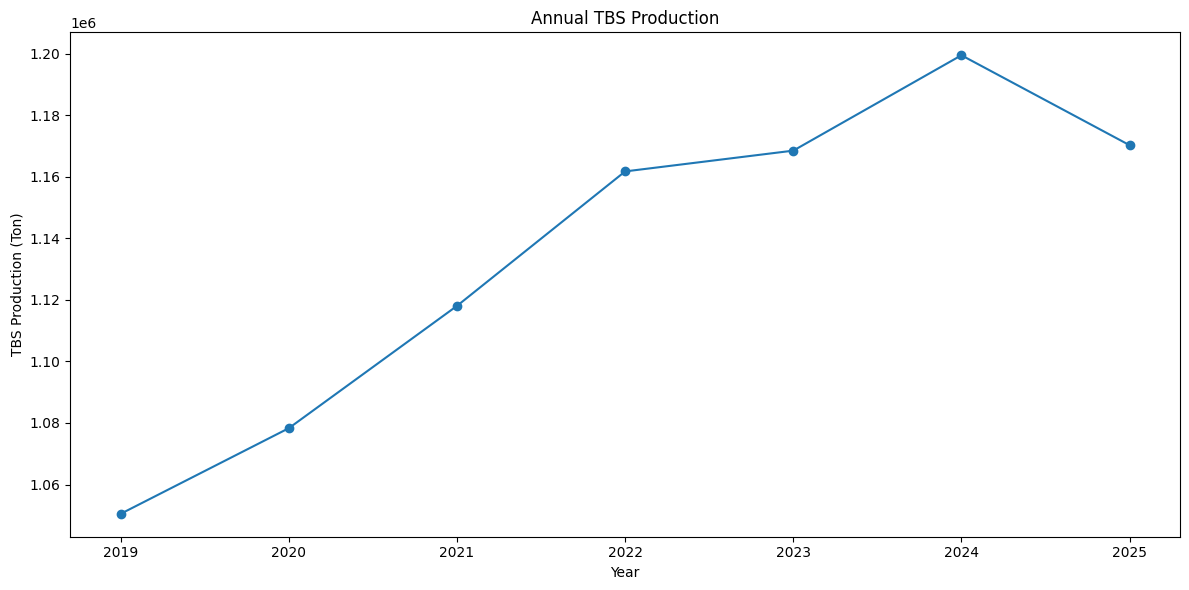

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    annual_production["year"],
    annual_production["tbs_production_ton"],
    marker="o"
)

plt.title("Annual TBS Production")
plt.xlabel("Year")
plt.ylabel("TBS Production (Ton)")
plt.xticks(annual_production["year"])

plt.tight_layout()
plt.show()

## Seasonality Analysis

In [ ]:
# hitung rata-rata produksi berdasarkan bulan
monthly_seasonality = (
    df.groupby("month")
      [["tbs_production_ton",
        "cpo_production_ton",
        "kernel_production_ton"]]
      .mean()
      .reset_index()
)

monthly_seasonality

,month,tbs_production_ton,cpo_production_ton,kernel_production_ton
0,1,8782.812857,1760.728571,434.597143
1,2,8946.038571,1802.561429,444.532857
2,3,9482.161429,1864.565714,472.515714
3,4,9840.593571,1987.670000,491.582857
4,5,9781.725714,1952.400000,488.005714
5,6,10152.437143,2013.264286,512.250000
6,7,10274.217143,2048.178571,519.958571
7,8,9775.897857,1950.950000,489.185714
8,9,9657.334286,1938.981429,487.652857
9,10,9231.337143,1813.861429,450.635714


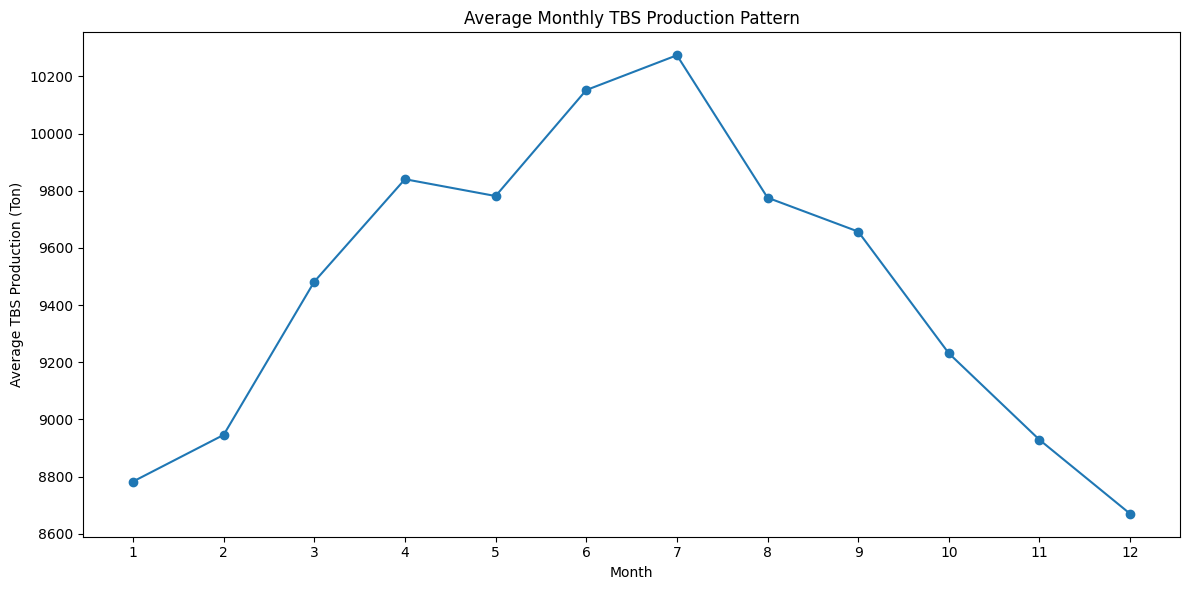

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_seasonality["month"],
    monthly_seasonality["tbs_production_ton"],
    marker="o"
)

plt.title("Average Monthly TBS Production Pattern")
plt.xlabel("Month")
plt.ylabel("Average TBS Production (Ton)")
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

## Production by Region

In [ ]:
region_production = (
    df.groupby("region")
      [["tbs_production_ton",
        "cpo_production_ton",
        "kernel_production_ton"]]
      .sum()
      .sort_values(
          "tbs_production_ton",
          ascending=False
      )
)

region_production

,tbs_production_ton,cpo_production_ton,kernel_production_ton
region,,,
Sumatra,4262393.55,853399.3,213322.5
Kalimantan,2336148.35,464385.1,116677.2
Sulawesi,1348092.20,267545.5,66617.8


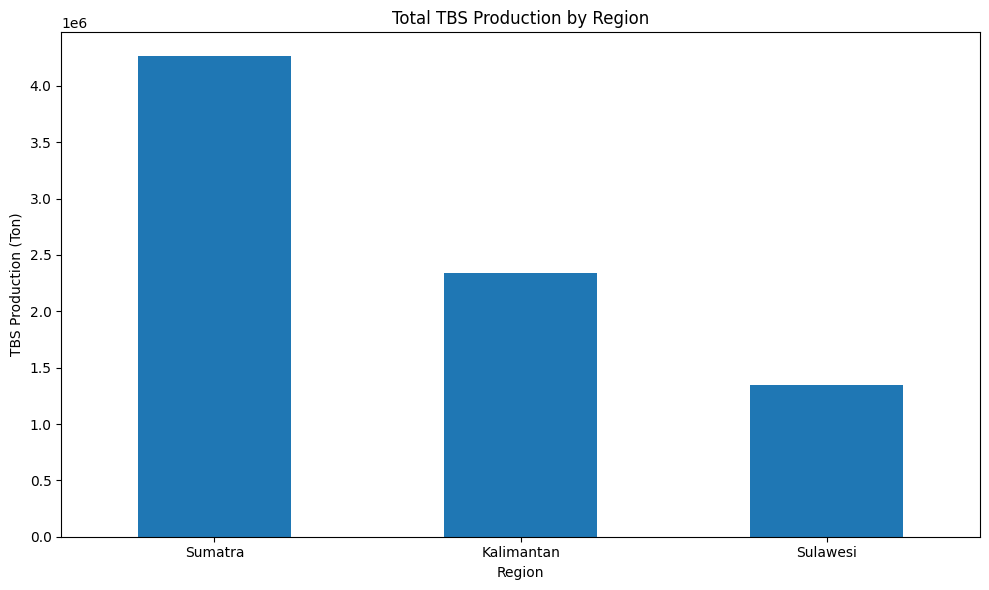

In [ ]:
region_production["tbs_production_ton"].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Total TBS Production by Region")
plt.xlabel("Region")
plt.ylabel("TBS Production (Ton)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Productivity by Region

In [ ]:
region_yield = (
    df.groupby("region")
      .agg(
          total_tbs=("tbs_production_ton", "sum"),
          total_area=("area_ha", "sum")
      )
)

region_yield["yield_ton_per_ha"] = (
    region_yield["total_tbs"] /
    (region_yield["total_area"] * 84)
)

region_yield
# 84 adalah jumlah bulan dalam periode 2019–2025.

,total_tbs,total_area,yield_ton_per_ha
region,,,
Kalimantan,2336148.35,1066800,0.026070
Sulawesi,1348092.20,663600,0.024184
Sumatra,4262393.55,1953000,0.025982


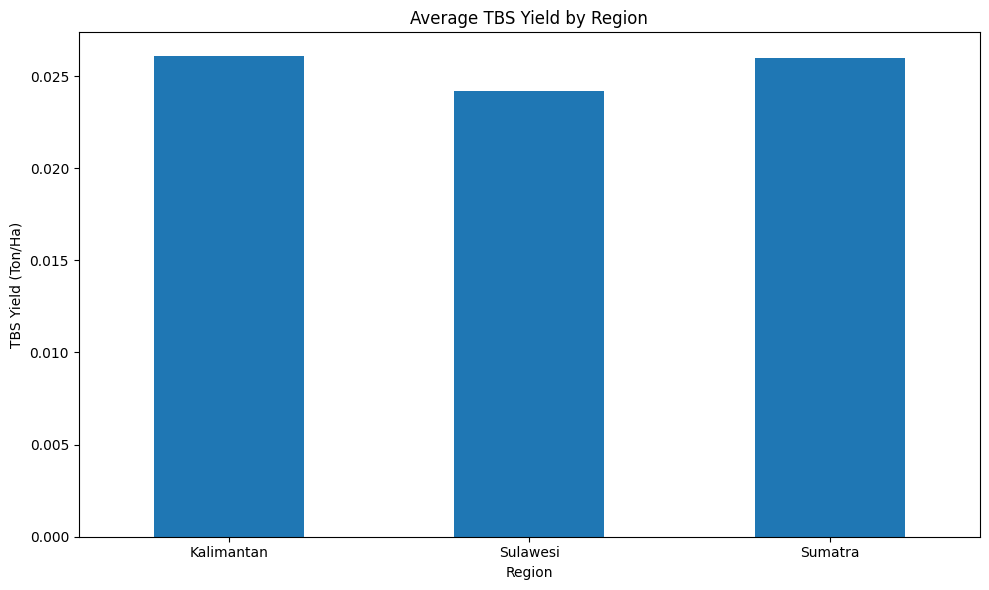

In [ ]:
region_yield["yield_ton_per_ha"].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average TBS Yield by Region")
plt.xlabel("Region")
plt.ylabel("TBS Yield (Ton/Ha)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Production by Estate

In [ ]:
estate_production = (
    df.groupby("estate_name")
      .agg(
          total_tbs=("tbs_production_ton", "sum"),
          area_ha=("area_ha", "first")
      )
)

estate_production["avg_monthly_yield"] = (
    estate_production["total_tbs"] /
    estate_production["area_ha"] /
    84
)

estate_production.sort_values(
    "avg_monthly_yield",
    ascending=False
)

,total_tbs,area_ha,avg_monthly_yield
estate_name,,,
Estate Jambi 01,863009.50,4600,2.233461
Estate Riau 01,1029980.30,5500,2.229395
Estate Kalteng 01,879248.30,4700,2.227073
Estate Kalbar 01,752857.05,4100,2.185996
Estate Lampung 01,778829.60,4250,2.181596
Estate Kaltim 01,704043.00,3900,2.149093
Estate Sumsel 01,915794.75,5100,2.137710
Estate Lampung 02,674779.40,3800,2.113971
Estate Sulawesi 02,755065.40,4300,2.090436


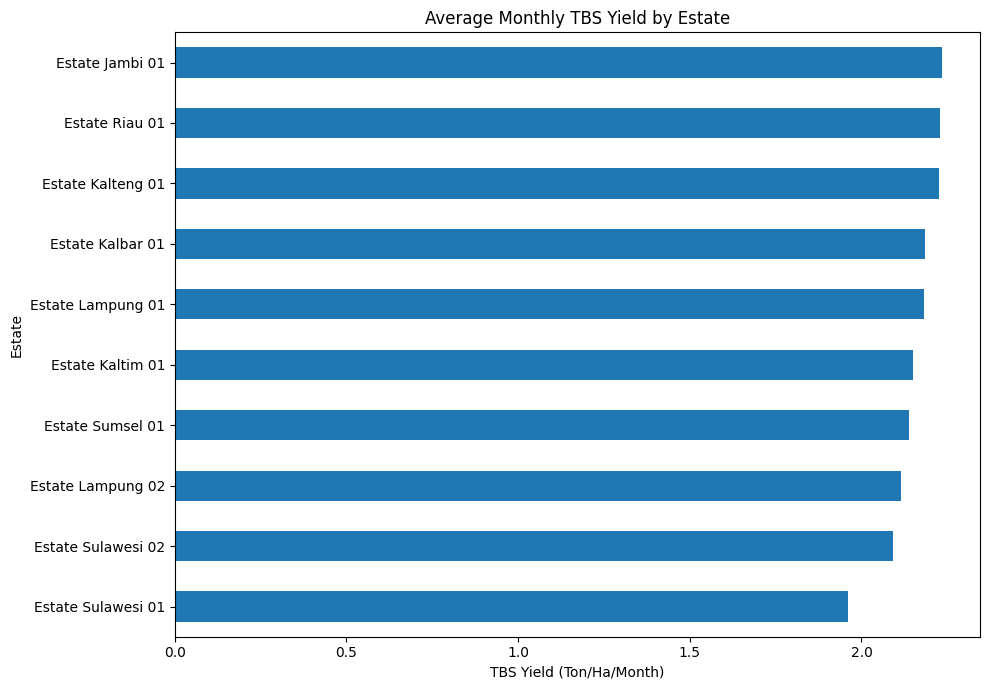

In [ ]:
estate_production = estate_production.sort_values(
    "avg_monthly_yield"
)

estate_production["avg_monthly_yield"].plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Average Monthly TBS Yield by Estate")
plt.xlabel("TBS Yield (Ton/Ha/Month)")
plt.ylabel("Estate")

plt.tight_layout()
plt.show()

## Plant Age vs Productivity

In [ ]:
age_yield = (
    df.groupby("plant_age_years")
      .agg(
          avg_yield=("tbs_yield_ton_per_ha", "mean"),
          observations=("tbs_yield_ton_per_ha", "count")
      )
      .reset_index()
)

age_yield.head()

,plant_age_years,avg_yield,observations
0,5,1.759446,12
1,6,2.019353,24
2,7,1.999403,48
3,8,1.959006,72
4,9,1.977849,96


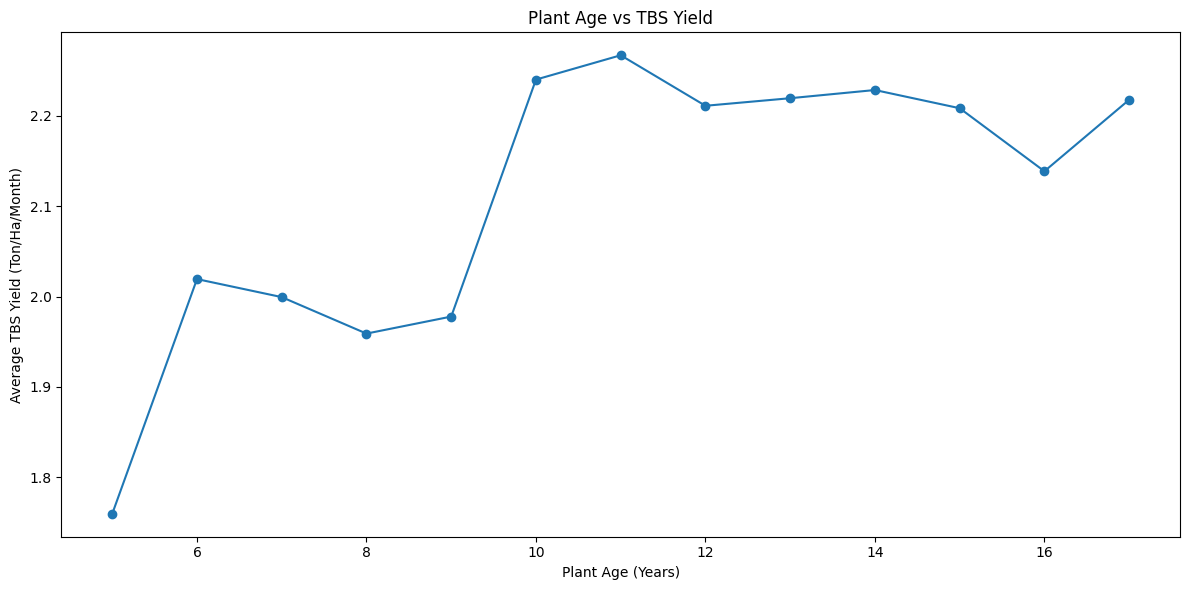

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    age_yield["plant_age_years"],
    age_yield["avg_yield"],
    marker="o"
)

plt.title("Plant Age vs TBS Yield")
plt.xlabel("Plant Age (Years)")
plt.ylabel("Average TBS Yield (Ton/Ha/Month)")

plt.tight_layout()
plt.show()

## Rainfall vs TBS Production

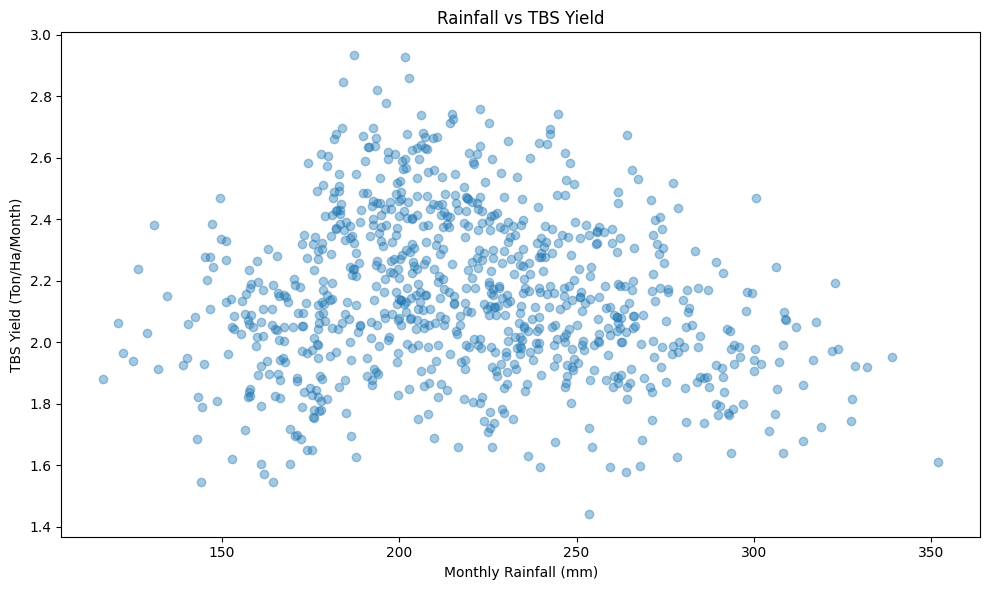

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["rainfall_mm"],
    df["tbs_yield_ton_per_ha"],
    alpha=0.4
)

plt.title("Rainfall vs TBS Yield")
plt.xlabel("Monthly Rainfall (mm)")
plt.ylabel("TBS Yield (Ton/Ha/Month)")

plt.tight_layout()
plt.show()

## Rainfall Bucket Analysis

In [ ]:
df["rainfall_category"] = pd.cut(
    df["rainfall_mm"],
    bins=[0, 120, 180, 280, 350, np.inf],
    labels=[
        "Very Low",
        "Low",
        "Optimal",
        "High",
        "Very High"
    ]
)

In [ ]:
rainfall_analysis = (
    df.groupby("rainfall_category", observed=False)
      ["tbs_yield_ton_per_ha"]
      .mean()
)

rainfall_analysis

,tbs_yield_ton_per_ha
rainfall_category,
Very Low,1.881209
Low,2.039637
Optimal,2.204219
High,1.954689
Very High,1.611415


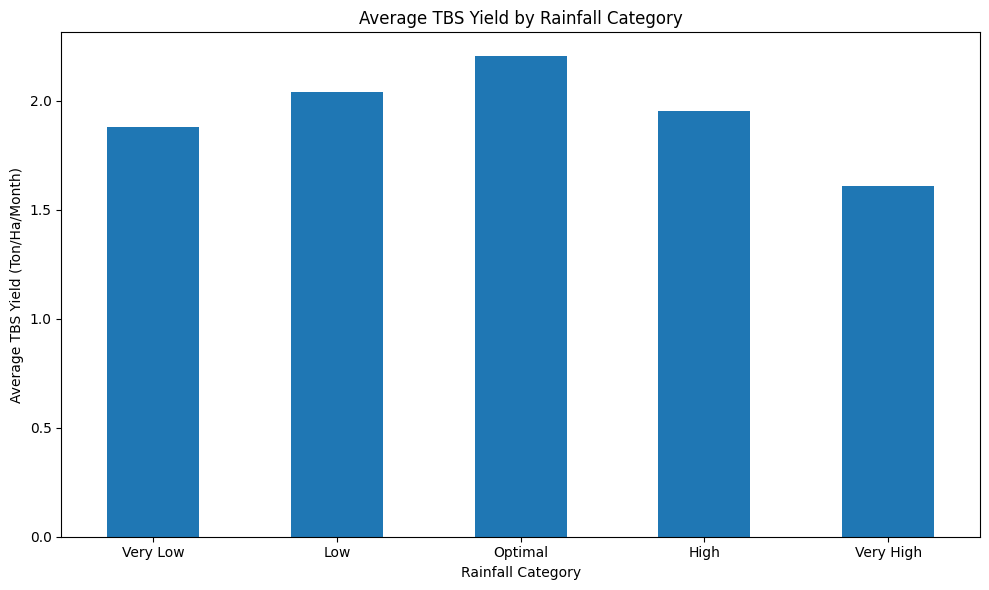

In [ ]:
rainfall_analysis.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average TBS Yield by Rainfall Category")
plt.xlabel("Rainfall Category")
plt.ylabel("Average TBS Yield (Ton/Ha/Month)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Fertilizer vs Production

In [ ]:
df["fertilizer_kg_per_ha"] = (
    df["fertilizer_kg"] /
    df["area_ha"]
)

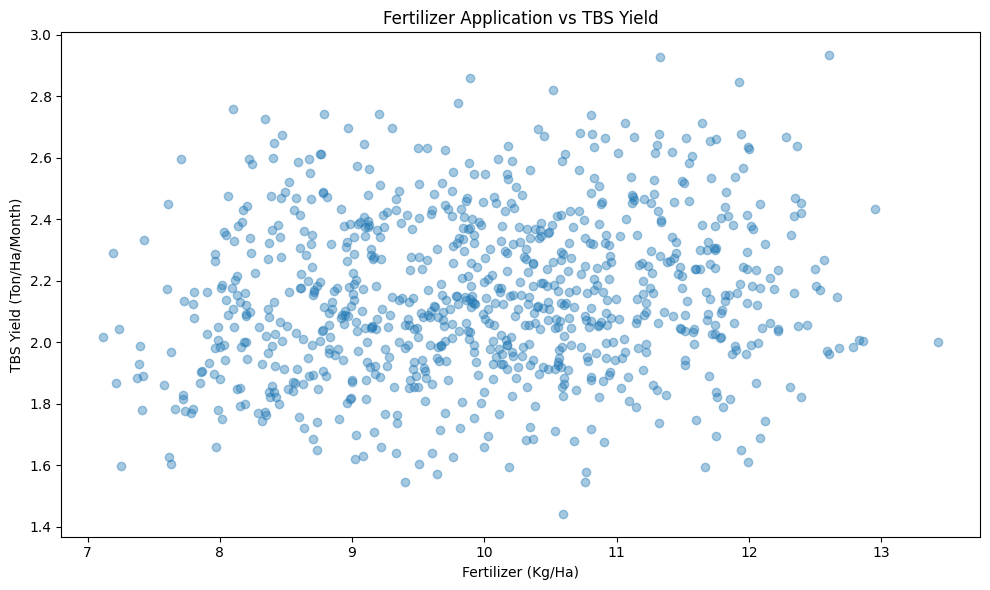

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["fertilizer_kg_per_ha"],
    df["tbs_yield_ton_per_ha"],
    alpha=0.4
)

plt.title("Fertilizer Application vs TBS Yield")
plt.xlabel("Fertilizer (Kg/Ha)")
plt.ylabel("TBS Yield (Ton/Ha/Month)")

plt.tight_layout()
plt.show()

## Operational Disruption vs Production

In [ ]:
disruption_analysis = (
    df.groupby("disruption_days")
      ["tbs_yield_ton_per_ha"]
      .mean()
)

disruption_analysis

,tbs_yield_ton_per_ha
disruption_days,
0.0,2.204776
1.0,2.169665
2.0,2.102636
3.0,2.082305
4.0,1.904132
5.0,1.964703


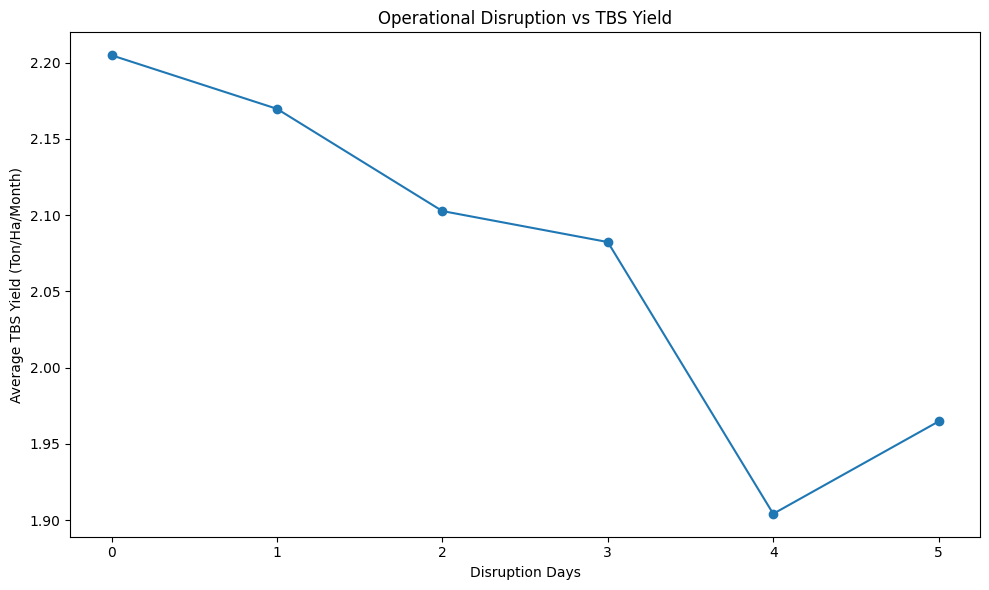

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    disruption_analysis.index,
    disruption_analysis.values,
    marker="o"
)

plt.title("Operational Disruption vs TBS Yield")
plt.xlabel("Disruption Days")
plt.ylabel("Average TBS Yield (Ton/Ha/Month)")

plt.tight_layout()
plt.show()

## Working Days vs Production

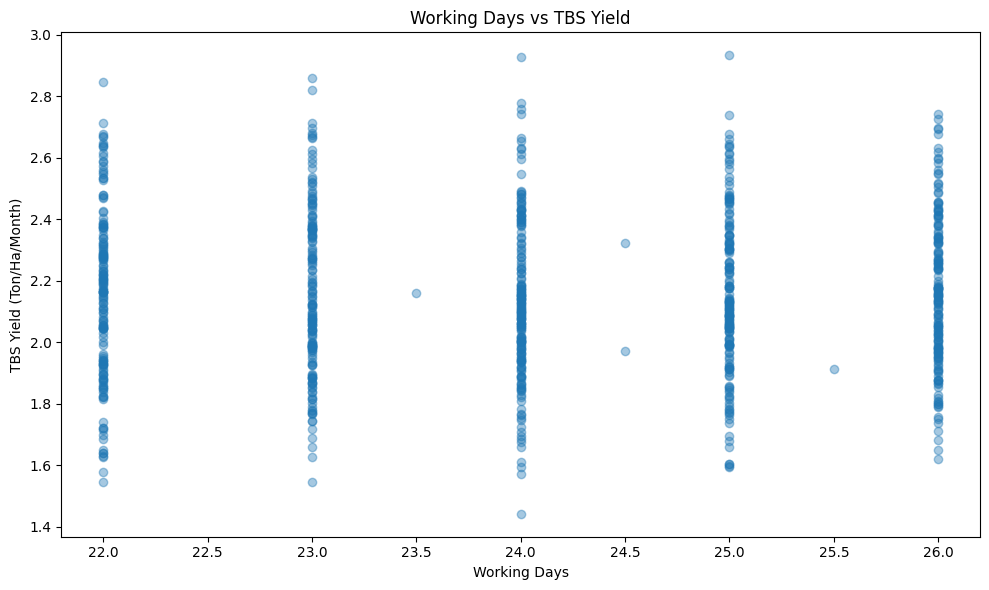

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["working_days"],
    df["tbs_yield_ton_per_ha"],
    alpha=0.4
)

plt.title("Working Days vs TBS Yield")
plt.xlabel("Working Days")
plt.ylabel("TBS Yield (Ton/Ha/Month)")

plt.tight_layout()
plt.show()

## Correlation Analysis

In [ ]:
numeric_cols = [
    "rainfall_mm",
    "rainy_days",
    "fertilizer_kg_per_ha",
    "working_days",
    "disruption_days",
    "plant_age_years",
    "tbs_yield_ton_per_ha",
    "cpo_extraction_rate",
    "kernel_extraction_rate"
]

corr_matrix = df[numeric_cols].corr()

corr_matrix

,rainfall_mm,rainy_days,fertilizer_kg_per_ha,working_days,disruption_days,plant_age_years,tbs_yield_ton_per_ha,cpo_extraction_rate,kernel_extraction_rate
rainfall_mm,1.000000,0.872832,-0.038630,0.017334,-0.016573,-0.075954,-0.127085,0.014323,-0.046984
rainy_days,0.872832,1.000000,-0.040195,0.006332,-0.017932,-0.058980,-0.082903,0.018113,-0.033581
fertilizer_kg_per_ha,-0.038630,-0.040195,1.000000,0.030532,0.040846,0.023487,0.144319,-0.022120,0.001155
working_days,0.017334,0.006332,0.030532,1.000000,0.046336,0.005317,-0.003171,0.035933,0.011172
disruption_days,-0.016573,-0.017932,0.040846,0.046336,1.000000,0.033558,-0.216256,-0.047903,0.028366
plant_age_years,-0.075954,-0.058980,0.023487,0.005317,0.033558,1.000000,0.327326,0.034010,0.008345
tbs_yield_ton_per_ha,-0.127085,-0.082903,0.144319,-0.003171,-0.216256,0.327326,1.000000,0.034743,0.033593
cpo_extraction_rate,0.014323,0.018113,-0.022120,0.035933,-0.047903,0.034010,0.034743,1.000000,0.047466
kernel_extraction_rate,-0.046984,-0.033581,0.001155,0.011172,0.028366,0.008345,0.033593,0.047466,1.000000


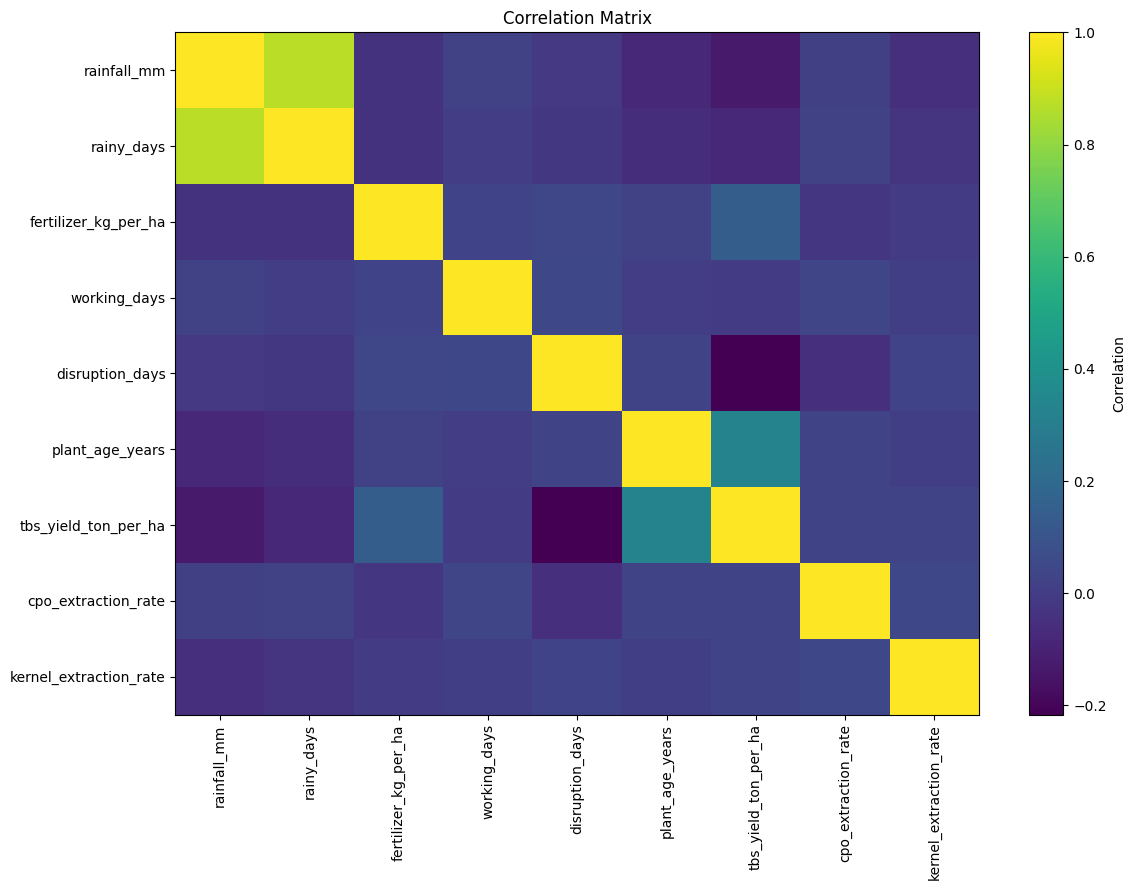

In [ ]:
plt.figure(figsize=(12, 9))

plt.imshow(corr_matrix, aspect="auto")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.colorbar(label="Correlation")

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

## CPO Extraction Rate

In [ ]:
df["cpo_extraction_rate"].describe()

,cpo_extraction_rate
count,840.000000
mean,0.199413
std,0.014990
min,0.154350
25%,0.188569
50%,0.199095
75%,0.210496
max,0.232326


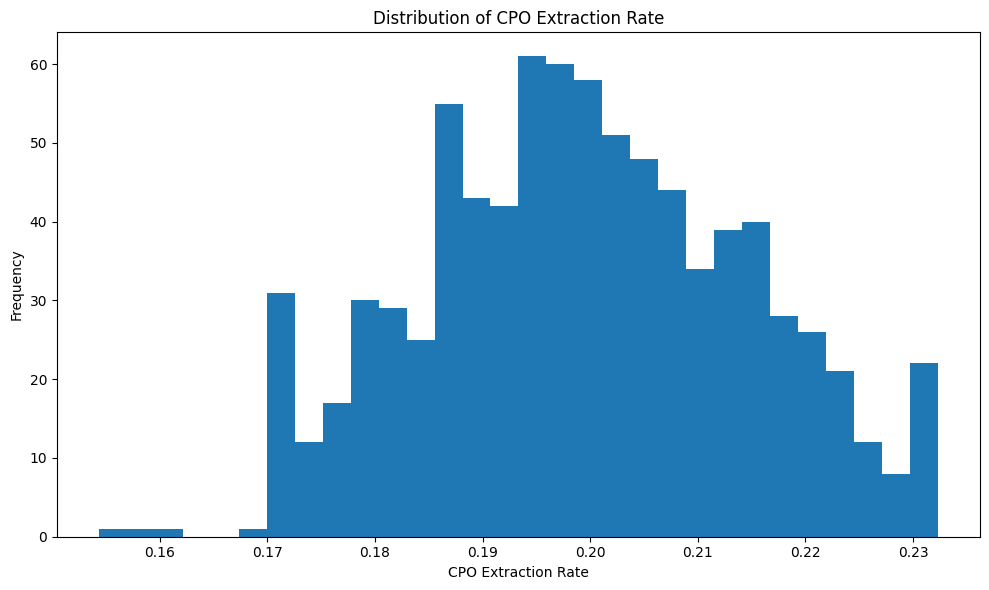

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["cpo_extraction_rate"],
    bins=30
)

plt.title("Distribution of CPO Extraction Rate")
plt.xlabel("CPO Extraction Rate")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

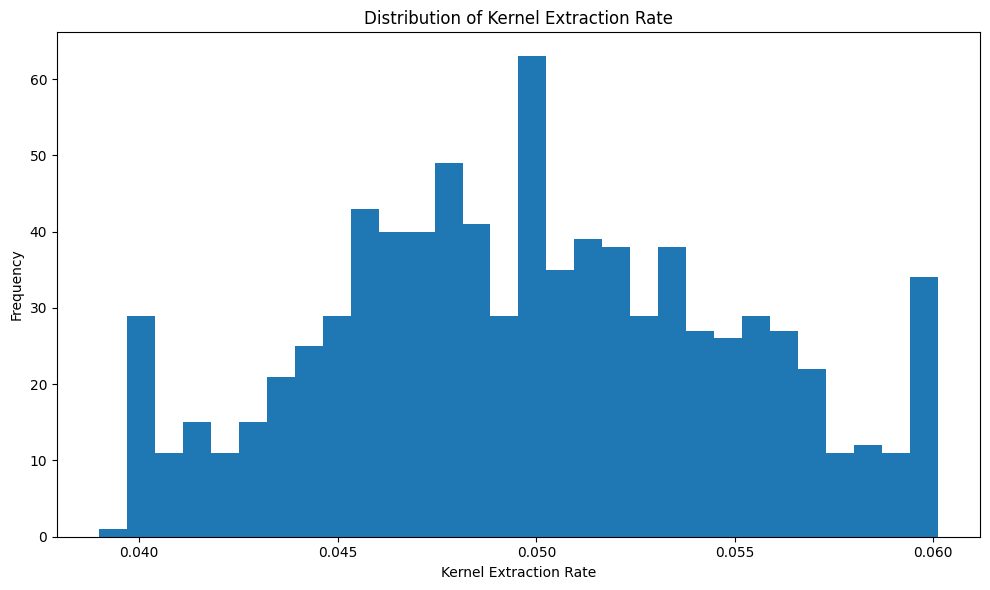

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["kernel_extraction_rate"],
    bins=30
)

plt.title("Distribution of Kernel Extraction Rate")
plt.xlabel("Kernel Extraction Rate")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Cek Outlier Secara Visual

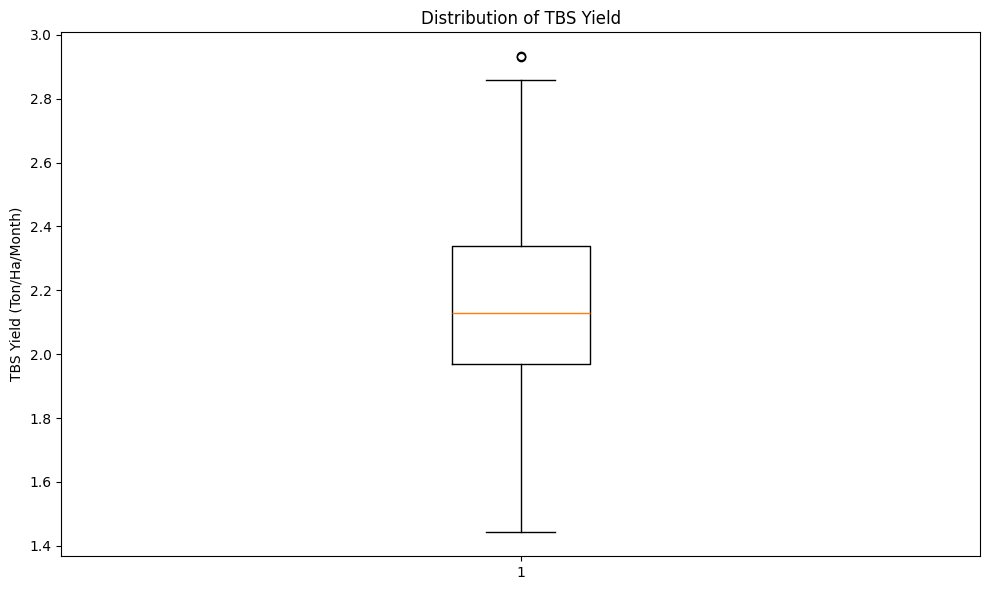

In [ ]:
# production
plt.figure(figsize=(10, 6))

plt.boxplot(
    df["tbs_yield_ton_per_ha"].dropna()
)

plt.title("Distribution of TBS Yield")
plt.ylabel("TBS Yield (Ton/Ha/Month)")

plt.tight_layout()
plt.show()

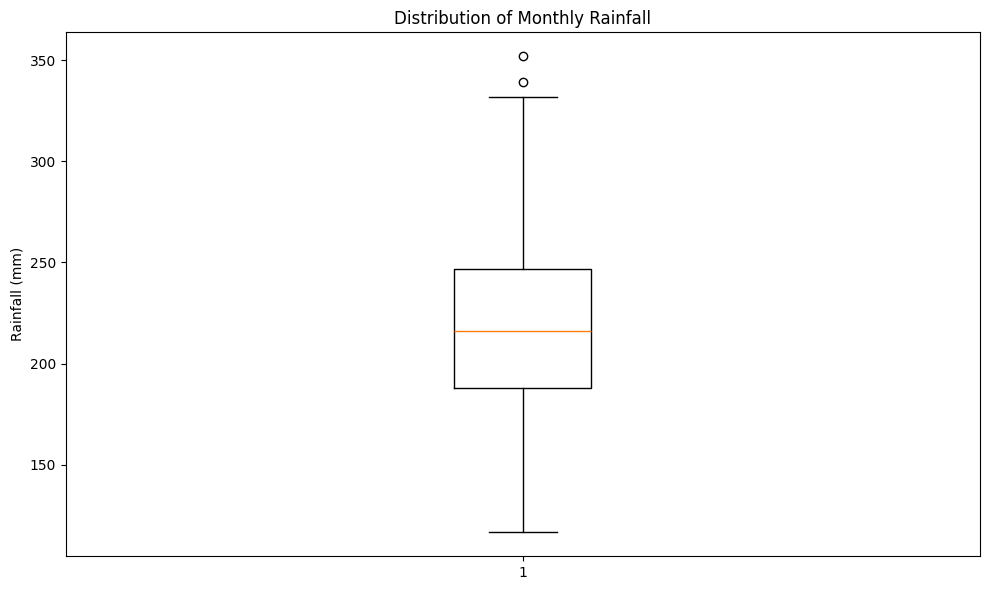

In [ ]:
# rainfall
plt.figure(figsize=(10, 6))

plt.boxplot(
    df["rainfall_mm"].dropna()
)

plt.title("Distribution of Monthly Rainfall")
plt.ylabel("Rainfall (mm)")

plt.tight_layout()
plt.show()

## Aggregate Monthly Dataset

In [ ]:
monthly_df = (
    df.groupby("date")
      .agg(
          tbs_production_ton=(
              "tbs_production_ton",
              "sum"
          ),
          cpo_production_ton=(
              "cpo_production_ton",
              "sum"
          ),
          kernel_production_ton=(
              "kernel_production_ton",
              "sum"
          ),
          rainfall_avg=(
              "rainfall_mm",
              "mean"
          ),
          fertilizer_total_kg=(
              "fertilizer_kg",
              "sum"
          ),
          disruption_days=(
              "disruption_days",
              "sum"
          )
      )
      .reset_index()
)

In [ ]:
monthly_df.head()

,date,tbs_production_ton,cpo_production_ton,kernel_production_ton,rainfall_avg,fertilizer_total_kg,disruption_days
0,2019-01-01,83868.8,16747.1,4440.5,264.280,452338.0,3.0
1,2019-02-01,83608.7,16509.9,4169.4,244.160,432086.0,10.0
2,2019-03-01,86983.6,17265.3,4250.6,224.645,433900.0,9.0
3,2019-04-01,87586.5,17829.3,4332.6,210.710,437557.0,9.0
4,2019-05-01,89200.0,17934.6,4545.4,198.420,416108.0,7.0


In [ ]:
monthly_df.shape

(84, 7)

## Save EDA Dataset

In [ ]:
monthly_df.to_csv(
    PROCESSED_DIR / "monthly_aggregated.csv",
    index=False
)

In [ ]:
df.to_csv(
    PROCESSED_DIR / "eda_dataset.csv",
    index=False
)

## Candidate Features

In [ ]:
candidate_features = [
    "plant_age_years",
    "rainfall_mm",
    "rainy_days",
    "fertilizer_kg_per_ha",
    "working_days",
    "disruption_days"
]

target_variables = [
    "tbs_production_ton",
    "cpo_production_ton",
    "kernel_production_ton"
]

print("Candidate Features:")
for feature in candidate_features:
    print("-", feature)

print("\nTarget Variables:")
for target in target_variables:
    print("-", target)

Candidate Features:
- plant_age_years
- rainfall_mm
- rainy_days
- fertilizer_kg_per_ha
- working_days
- disruption_days

Target Variables:
- tbs_production_ton
- cpo_production_ton
- kernel_production_ton
